## Setup

In [2]:
library(auk)

auk 0.8.0 is designed for EBD files downloaded after 2024-10-29. 
No EBD data directory set, see ?auk_set_ebd_path to set EBD_PATH 
eBird taxonomy version:  2024



In [ ]:
library(tidyverse)

library(magrittr)
library(httr)
library(data.table)
library(plotly)
library(elevatr)
library(readr)
library(raster)

library(sf)
library(terra)
library(rnaturalearth)
library(dggridR)
library(lubridate)
library(hms)

library(gridExtra)

select <- dplyr::select
projection <- raster::projection

# readRenviron("~/.Renviron")
# R.home()

# detach("package:raster", unload=TRUE)

Citation:  
*eBird Basic Dataset. Version: EBD_relSep-2025. Cornell Lab of Ornithology, Ithaca, New York. Sep 2025.*

In [5]:
PROJECT_DIR = getwd()
smpl_dir = file.path(PROJECT_DIR, "source_data", "ebd-datafile-SAMPLE")
ebd_smpl_filename = "ebd_US-AL-125_202503_202503_smp_relMar-2025.txt"
sed_smpl_filename = "ebd_US-AL-125_202503_202503_smp_relMar-2025_sampling.txt"

ebd_full_dir = file.path(PROJECT_DIR, "source_data", "ebd_relSep-2025")
ebd_full_filename = "ebd_relSep-2025.txt"

sed_full_dir = file.path(PROJECT_DIR, "source_data", "ebd_sampling_relSep-2025")
sed_full_filename = "ebd_sampling_relSep-2025.txt"

In [6]:
source("ebd_functions.R")

In [ ]:
dist_to_coast_df = read_in_dist_to_coast_data(file.path(PROJECT_DIR, "source_data", "NASA_dist2coast.txt"))

### Meta

In [2]:
auk_version()

$auk_version
[1] "auk 0.8.0"

$ebd_version
[1] "2024-10-29"

$taxonomy_version
[1] 2024

In [ ]:
auk_ebd_version(file.path(ebd_full_dir, ebd_full_filename))

$ebd_version
[1] "2025-09-01"

$taxonomy_version
[1] 2025

## Osprey, 2024, SC
---

In [ ]:
f_out_ebd_only_osp <- file.path(PROJECT_DIR, "output", "auk", "ebd_osprey_20251130.txt")
f_out_sed_only_osp <- file.path(PROJECT_DIR, "output", "auk", "sed_osprey_20251130.txt")

In [ ]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Osprey") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_osp, file_sampling = f_out_sed_only_osp, overwrite = TRUE)

## Osprey, 2024, US
---

In [9]:
f_out_ebd_only_osp <- file.path(PROJECT_DIR, "output", "auk", "ebd_osprey_20251206.txt")
f_out_sed_only_osp <- file.path(PROJECT_DIR, "output", "auk", "sed_osprey_20251206.txt")

In [ ]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Osprey") %>%
    auk_country("United States") %>%
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_osp, file_sampling = f_out_sed_only_osp, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Osprey"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/ebd_osprey_20251130.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/sed_osprey_20251130.txt 

Filters 
  Species: Pandion haliaetus
  Countries: US
  States: all
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

In [7]:
f_out_ebd_only_osp2 <- file.path(PROJECT_DIR, "output", "auk", "ebd_osprey_20251206_sub.txt")
f_out_sed_only_osp2 <- file.path(PROJECT_DIR, "output", "auk", "sed_osprey_20251206_sub.txt")

In [10]:
# SUB-dataset filtering
f_in_ebd <- f_out_ebd_only_osp
f_in_sed <- f_out_sed_only_osp
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Osprey") %>%
    auk_country("United States") %>%
    auk_state(c("US-FL", "US-AL", "US-GA", "US-SC", "US-NC", "US-VA", "US-TN")) %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_osp2, file_sampling = f_out_sed_only_osp2, overwrite = TRUE)

Input 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/ebd_osprey_20251206.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/sed_osprey_20251206.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/ebd_osprey_20251206_sub.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/sed_osprey_20251206_sub.txt 

Filters 
  Species: Pandion haliaetus
  Countries: all
  States: US-AL, US-FL, US-GA, US-NC, US-SC, US-TN, US-VA
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Pileated Woodpecker, 2024, SC
---

In [15]:
f_out_ebd_only_pwo <- file.path(PROJECT_DIR, "output", "ebd_pileated_woodpecker_20251130.txt")
f_out_sed_only_pwo <- file.path(PROJECT_DIR, "output", "sed_pileated_woodpecker_20251130.txt")

In [ ]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Pileated Woodpecker") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_pwo, file_sampling = f_out_sed_only_pwo, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Pileated Woodpecker"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_pileated_woodpecker_.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_pileated_woodpecker_.txt 

Filters 
  Species: Dryocopus pileatus
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Pileated Woodpecker, 2024, US
---

In [11]:
f_out_ebd_only_pwo <- file.path(PROJECT_DIR, "output", "auk", "ebd_pileated_woodpecker_20251206.txt")
f_out_sed_only_pwo <- file.path(PROJECT_DIR, "output", "auk", "sed_pileated_woodpecker_20251206.txt")

In [5]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Pileated Woodpecker") %>%
    auk_country("United States") %>%
    # auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_pwo, file_sampling = f_out_sed_only_pwo, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Pileated Woodpecker"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_pileated_woodpecker_20251206.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_pileated_woodpecker_20251206.txt 

Filters 
  Species: Dryocopus pileatus
  Countries: US
  States: all
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

In [12]:
f_out_ebd_only_pwo2 <- file.path(PROJECT_DIR, "output", "auk", "ebd_pileated_woodpecker_20251206_sub.txt")
f_out_sed_only_pwo2 <- file.path(PROJECT_DIR, "output", "auk", "sed_pileated_woodpecker_20251206_sub.txt")

In [13]:
# SUB-dataset filtering
f_in_ebd <- f_out_ebd_only_pwo
f_in_sed <- f_out_sed_only_pwo
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Osprey") %>%
    auk_country("United States") %>%
    auk_state(c("US-FL", "US-AL", "US-GA", "US-SC", "US-NC", "US-VA", "US-TN")) %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_pwo2, file_sampling = f_out_sed_only_pwo2, overwrite = TRUE)

Input 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/ebd_pileated_woodpecker_20251206.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/sed_pileated_woodpecker_20251206.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/ebd_pileated_woodpecker_20251206_sub.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/auk/sed_pileated_woodpecker_20251206_sub.txt 

Filters 
  Species: Pandion haliaetus
  Countries: all
  States: US-AL, US-FL, US-GA, US-NC, US-SC, US-TN, US-VA
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Short-eared Owl, 2024, SC
---

In [35]:
f_out_ebd_only_seo <- file.path(PROJECT_DIR, "output", "ebd_short-eared_owl_20251130.txt")
f_out_sed_only_seo <- file.path(PROJECT_DIR, "output", "sed_short-eared_owl_20251130.txt")

In [36]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Short-eared Owl") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_seo, file_sampling = f_out_sed_only_seo, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Short-eared Owl"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_short-eared_owl_20251130.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_short-eared_owl_20251130.txt 

Filters 
  Species: Asio flammeus
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Great Horned Owl, 2024, SC
---

In [37]:
f_out_ebd_only_gho <- file.path(PROJECT_DIR, "output", "ebd_great_horned_owl_20251130.txt")
f_out_sed_only_gho <- file.path(PROJECT_DIR, "output", "sed_great_horned_owl_20251130.txt")

In [38]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Great Horned Owl") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_gho, file_sampling = f_out_sed_only_gho, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Great Horned Owl"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_great_horned_owl_20251130.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_great_horned_owl_20251130.txt 

Filters 
  Species: Bubo virginianus
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Red-tailed Hawk, 2024, SC
---

In [39]:
f_out_ebd_only_rth <- file.path(PROJECT_DIR, "output", "ebd_red-tailed_hawk_20251201.txt")
f_out_sed_only_rth <- file.path(PROJECT_DIR, "output", "sed_red-tailed_hawk_20251201.txt")

In [40]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Red-tailed Hawk") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_rth, file_sampling = f_out_sed_only_rth, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Red-tailed Hawk"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_red-tailed_hawk_20251201.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_red-tailed_hawk_20251201.txt 

Filters 
  Species: Buteo jamaicensis
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## American Barn Owl, 2024, SC
---

In [41]:
f_out_ebd_only_abo <- file.path(PROJECT_DIR, "output", "ebd_american_barn_owl_20251201.txt")
f_out_sed_only_abo <- file.path(PROJECT_DIR, "output", "sed_american_barn_owl_20251201.txt")

In [42]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("American Barn Owl") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_abo, file_sampling = f_out_sed_only_abo, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "American Barn Owl"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_american_barn_owl_20251201.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_american_barn_owl_20251201.txt 

Filters 
  Species: Tyto furcata
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Barred Owl, 2024, SC
---

In [43]:
f_out_ebd_only_bow <- file.path(PROJECT_DIR, "output", "ebd_barred_owl_20251201.txt")
f_out_sed_only_bow <- file.path(PROJECT_DIR, "output", "sed_barred_owl_20251201.txt")

In [44]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Barred Owl") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_bow, file_sampling = f_out_sed_only_bow, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Barred Owl"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_barred_owl_20251201.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_barred_owl_20251201.txt 

Filters 
  Species: Strix varia
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Cooper's Hawk, 2024, SC
---

In [45]:
f_out_ebd_only_cha <- file.path(PROJECT_DIR, "output", "ebd_coopers_hawk_20251201.txt")
f_out_sed_only_cha <- file.path(PROJECT_DIR, "output", "sed_coopers_hawk_20251201.txt")

In [46]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Cooper's Hawk") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_cha, file_sampling = f_out_sed_only_cha, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Cooper's Hawk"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_coopers_hawk_20251201.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_coopers_hawk_20251201.txt 

Filters 
  Species: Astur cooperii
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Red-headed Woodpecker, 2024, SC
---

In [47]:
f_out_ebd_only_rhw <- file.path(PROJECT_DIR, "output", "ebd_red-headed_woodpecker_20251201.txt")
f_out_sed_only_rhw <- file.path(PROJECT_DIR, "output", "sed_red-headed_woodpecker_20251201.txt")

In [48]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Red-headed Woodpecker") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only_rhw, file_sampling = f_out_sed_only_rhw, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Red-headed Woodpecker"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_red-headed_woodpecker_20251201.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_red-headed_woodpecker_20251201.txt 

Filters 
  Species: Melanerpes erythrocephalus
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

##
---

## Swallow-tailed Kite, 2024, SC
---

In [ ]:
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", "ebd_swallow-tailed_kite_20251202.txt")
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", "sed_swallow-tailed_kite_20251202.txt")

In [20]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Swallow-tailed Kite") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Swallow-tailed Kite"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_swallow-tailed_kite_20251202.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_swallow-tailed_kite_20251202.txt 

Filters 
  Species: Elanoides forficatus
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Turkey Vulture, 2024, SC
---

In [ ]:
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", "ebd_turkey_vulture_20251202.txt")
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", "sed_turkey_vulture_20251202.txt")

In [22]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Turkey Vulture") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Turkey Vulture"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_turkey_vulture_20251202.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_turkey_vulture_20251202.txt 

Filters 
  Species: Cathartes aura
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Brown-headed Nuthatch, 2024, SC
---

In [ ]:
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", "ebd_brown-headed_nuthatch_20251202.txt")
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", "sed_brown-headed_nuthatch_20251202.txt")

In [24]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Brown-headed Nuthatch") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Brown-headed Nuthatch"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_brown-headed_nuthatch_20251202.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_brown-headed_nuthatch_20251202.txt 

Filters 
  Species: Sitta pusilla
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

## Wood Stork, 2024, SC
---

In [ ]:
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", "ebd_wood_stork_20251202.txt")
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", "sed_wood_stork_20251202.txt")

In [26]:
# Full dataset filtering
f_in_ebd <- file.path(ebd_full_dir, ebd_full_filename)
f_in_sed <- file.path(sed_full_dir, sed_full_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species("Wood Stork") %>%
    auk_country("United States") %>%
    auk_state("US-SC") %>% 
    auk_complete() %>%
    auk_date(c("2024-01-01", "2024-12-31"))
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Wood Stork"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relSep-2025/ebd_relSep-2025.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relSep-2025/ebd_sampling_relSep-2025.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/ebd_wood_stork_20251202.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/STAT_420_Final_Project/output/sed_wood_stork_20251202.txt 

Filters 
  Species: Mycteria americana
  Countries: all
  States: US-SC
  Counties: all
  BCRs: all
  Bounding box: full extent
  Years: all
  Date: 2024-01-01 - 2024-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

##
---

##
---

#### Read data back in

In [10]:
ebd_only_df = read_ebd(f_out_ebd_only, unique=TRUE, rollup=TRUE) # do not need to use auk_unique() when unique=TRUE passed here. Same for auk_rollup()
sed_only_df = read_sampling(f_out_sed_only, unique=TRUE)

In [11]:
ebd_zf_df <- auk_zerofill(ebd_only_df, sampling_events = sed_only_df) %>%
    collapse_zerofill()

### Zero-fill and clean

In [12]:
# Convert Xs to N/A. Set distance to 0 for stationary checklists 
ebd_zf_df <- mutate(ebd_zf_df,
                    observation_count = if_else(observation_count == "X", 
                                                NA_character_, observation_count),
                    observation_count = as.integer(observation_count),
                    effort_distance_km = if_else(protocol_name == "Stationary", 
                                                 0, effort_distance_km))
table(ebd_zf_df$species_observed)
# Reduce effort variability
ebd_zf_df <- ebd_zf_df %>% 
  filter(duration_minutes <= 60 * 5,
         effort_distance_km <= 5,
         number_observers <= 5)
        #  number_observers <= 10)
# https://strimas.com/ebp-workshop/presabs.html
table(ebd_zf_df$species_observed)


FALSE  TRUE 
71221 10909 


FALSE  TRUE 
64863  8432 

In [462]:
ebd_zf_df_file = file.path(PROJECT_DIR, "output", "ebd_pileated_zf_20251129.csv")
write_csv(ebd_zf_df, ebd_zf_df_file)

#### read back in

In [ ]:
ebd_zf_df_file = file.path(PROJECT_DIR, "output", "ebd_pileated_zf_20251125.csv")
ebd_zf_df2 = read_csv(ebd_zf_df_file)
# ebd_zf_df2 = read.csv(ebd_zf_df_file)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 73806 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (22): checklist_id, country, country_code, state, state_code, county, c...
dbl   (8): bcr_code, latitude, longitude, project_identifiers, duration_minu...
lgl   (8): atlas_block, effort_area_ha, all_species_reported, breeding_code,...
dttm  (1): last_edited_date
date  (1): observation_date
time  (1): time_observations_started

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [155]:
str(ebd_zf_df)

tibble [73,806 × 41] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:73806] "S168916922" "S165604998" "S165421988" "S166489286" ...
 $ last_edited_date         : chr [1:73806] "2024-04-16 13:15:23.201754" "2024-03-22 13:56:00.933157" "2024-03-20 20:32:42.757268" "2025-08-22 06:35:57.831304" ...
 $ country                  : chr [1:73806] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:73806] "US" "US" "US" "US" ...
 $ state                    : chr [1:73806] "South Carolina" "South Carolina" "South Carolina" "South Carolina" ...
 $ state_code               : chr [1:73806] "US-SC" "US-SC" "US-SC" "US-SC" ...
 $ county                   : chr [1:73806] "Pickens" "Pickens" "Pickens" "Aiken" ...
 $ county_code              : chr [1:73806] "US-SC-077" "US-SC-077" "US-SC-077" "US-SC-003" ...
 $ iba_code                 : chr [1:73806] NA NA NA NA ...
 $ bcr_code                 : int [1:73806] 29 29 29 27 27 27 27 27 2

In [158]:
str(as_tibble(ebd_zf_df2))

tibble [73,806 × 41] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:73806] "S168916922" "S165604998" "S165421988" "S166489286" ...
 $ last_edited_date         : chr [1:73806] "2024-04-16 13:15:23.201754" "2024-03-22 13:56:00.933157" "2024-03-20 20:32:42.757268" "2025-08-22 06:35:57.831304" ...
 $ country                  : chr [1:73806] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:73806] "US" "US" "US" "US" ...
 $ state                    : chr [1:73806] "South Carolina" "South Carolina" "South Carolina" "South Carolina" ...
 $ state_code               : chr [1:73806] "US-SC" "US-SC" "US-SC" "US-SC" ...
 $ county                   : chr [1:73806] "Pickens" "Pickens" "Pickens" "Aiken" ...
 $ county_code              : chr [1:73806] "US-SC-077" "US-SC-077" "US-SC-077" "US-SC-003" ...
 $ iba_code                 : chr [1:73806] NA NA NA NA ...
 $ bcr_code                 : int [1:73806] 29 29 29 27 27 27 27 27 2

In [ ]:
head(ebd_zf_df2)

,checklist_id,last_edited_date,country,country_code,state,state_code,county,county_code,iba_code,bcr_code,⋯,all_species_reported,group_identifier,checklist_comments,scientific_name,breeding_code,breeding_category,behavior_code,age_sex,observation_count,species_observed
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>
1,S168916922,2024-04-16 13:15:23.201754,United States,US,South Carolina,US-SC,Pickens,US-SC-077,NA,29,⋯,TRUE,NA,NA,Dryocopus pileatus,NA,NA,NA,NA,0,FALSE
2,S165604998,2024-03-22 13:56:00.933157,United States,US,South Carolina,US-SC,Pickens,US-SC-077,NA,29,⋯,TRUE,NA,NA,Dryocopus pileatus,NA,NA,NA,NA,0,FALSE
3,S165421988,2024-03-20 20:32:42.757268,United States,US,South Carolina,US-SC,Pickens,US-SC-077,NA,29,⋯,TRUE,NA,NA,Dryocopus pileatus,NA,NA,NA,NA,0,FALSE
4,S166489286,2025-08-22 06:35:57.831304,United States,US,South Carolina,US-SC,Aiken,US-SC-003,NA,27,⋯,TRUE,NA,To the curve,Dryocopus pileatus,NA,NA,NA,NA,0,FALSE
5,S166488229,2024-03-30 11:37:32.491483,United States,US,South Carolina,US-SC,Aiken,US-SC-003,NA,27,⋯,TRUE,NA,A Stationary stop to record the Swallow-tailed Kite.,Dryocopus pileatus,NA,NA,NA,NA,0,FALSE
6,S192804519,2024-08-26 08:46:41.84928,United States,US,South Carolina,US-SC,Aiken,US-SC-003,NA,27,⋯,TRUE,NA,Swallows were on utility line beside first field after pavement ends.,Dryocopus pileatus,NA,NA,NA,NA,1,TRUE


---

---

### Filter

In [169]:
# function to convert time observation to hours since midnight
time_to_decimal <- function(x) {
  x <- as_hms(x)
  hour(x) + minute(x) / 60 + second(x) / 3600
}

ebd_zf_df <- ebd_zf_df |> 
  mutate(
    # convert count to integer and X to NA
    # ignore the warning "NAs introduced by coercion"
    observation_count = as.integer(observation_count),
    # effort_distance_km to 0 for stationary counts
    effort_distance_km = if_else(protocol_name == "Stationary", 
                                 0, effort_distance_km),
    # convert duration to hours
    effort_hours = duration_minutes / 60,
    # speed km/h
    effort_speed_kmph = effort_distance_km / effort_hours,
    # convert time to decimal hours since midnight
    hours_of_day = time_to_decimal(time_observations_started),
    # split date into year and day of year
    year = year(observation_date),
    day_of_year = yday(observation_date)
  )

ebd_zf_df_filtered <- ebd_zf_df |> 
  filter(protocol_name %in% c("Stationary", "Traveling"),
         effort_hours <= 6,
         effort_hours >= 15/60, # added minimum duration
         effort_distance_km <= 10,
         effort_speed_kmph <= 100,
         number_observers <= 10) # (already filtered to <=5 above)
# https://ebird.github.io/ebird-best-practices/ebird.html#sec-ebird-effort

### Aggregation

In [298]:
dggs <- dgconstruct(spacing = 10)

# get hexagonal cell id and week number for each checklist
# ebird <- read_csv(ebd_zf_df_file) %>%     # getting errors reading back in
ebird_filtered <- ebd_zf_df_filtered |>
  mutate(cell = dgGEO_to_SEQNUM(dggs, longitude, latitude)$seqnum,
         year = year(observation_date),
         week = week(observation_date))
# https://strimas.com/ebp-workshop/subsampling.html
str(ebird_filtered)

Resolution: 12, Area (km^2): 95.9778454662114, Spacing (km): 9.67579208698331, CLS (km): 11.0545373458563
tibble [54,617 × 48] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:54617] "S166489286" "S192804519" "S160968636" "S204446437" ...
 $ last_edited_date         : chr [1:54617] "2025-08-22 06:35:57.831304" "2024-08-26 08:46:41.84928" "2025-08-24 20:59:57.935009" "2024-12-04 09:31:29.78307" ...
 $ country                  : chr [1:54617] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:54617] "US" "US" "US" "US" ...
 $ state                    : chr [1:54617] "South Carolina" "South Carolina" "South Carolina" "South Carolina" ...
 $ state_code               : chr [1:54617] "US-SC" "US-SC" "US-SC" "US-SC" ...
 $ county                   : chr [1:54617] "Aiken" "Aiken" "Aiken" "Aiken" ...
 $ county_code              : chr [1:54617] "US-SC-003" "US-SC-003" "US-SC-003" "US-SC-003" ...
 $ iba_code                 : c

In [314]:
# store hex cells as polygons for later use
hex_polygons_list <- dgcellstogrid(dggs, cells = ebird_filtered$cell)  # returns a SpatialPolygonsDataFrame
hex_polygons_list$cell <- hex_polygons_list$seqnum # Need to match ebd df col name
# convert to terra SpatVector
hex_spatvector <- vect(hex_polygons_list)  # terra function
# ChatGPT helped with this part.

In [ ]:
# Can merge into full df if needed, but I think I'll wait till later and just join as needed.
(ebird_hex_spatvector <- merge(hex_spatvector, ebird_filtered, by = "cell", all.x = TRUE))

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 54617, 49  (geometries, attributes)
 extent      : -83.45269, -78.51422, 32.02934, 35.27264  (xmin, xmax, ymin, ymax)
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :      cell    seqnum checklist_id last_edited_date       country
 type        :     <num>     <num>        <chr>            <chr>         <chr>
 values      : 4.935e+05 4.935e+05    G15609081  2025-09-22 15:~ United States
               4.935e+05 4.935e+05   S192763537  2025-08-14 05:~ United States
               4.935e+05 4.935e+05   S169072534  2025-08-21 05:~ United States
 country_code          state state_code     county county_code (and 39 more)
        <chr>          <chr>      <chr>      <chr>       <chr>              
           US South Carolina      US-SC    Pickens   US-SC-077              
           US South Carolina      US-SC Greenville   US-SC-045              
           US South Carolina      US-SC Greenville   US-SC-045       

In [424]:
ebird_filtered_agg <- ebird_filtered %>% 
  group_by(cell) %>% 
  # summarize(obs_freq = mean(observation_count)) %>% 
  summarize(n_checklists = n(),
            n_detected = sum(species_observed),
            det_freq = mean(species_observed),
            mean_num_observers = mean(number_observers),
            mean_start_time_hr = mean(hours_of_day),
            med_duration = median(effort_hours),
            mean_dist_km = mean(effort_distance_km)) %>% 
  ungroup() %>%
  mutate(cell_ctr_lat = dgSEQNUM_to_GEO(dggs, cell)$lat_deg,
         cell_ctr_lon = dgSEQNUM_to_GEO(dggs, cell)$lon_deg)
# https://www.rdocumentation.org/packages/dggridR/versions/3.1.0/topics/dgSEQNUM_to_GEO

In [425]:
str(ebird_filtered_agg)

tibble [728 × 10] (S3: tbl_df/tbl/data.frame)
 $ cell              : num [1:728] 493475 493476 493477 493478 493479 ...
 $ n_checklists      : int [1:728] 1 11 164 20 10 2 35 5 15 86 ...
 $ n_detected        : int [1:728] 0 8 77 4 5 0 10 2 5 20 ...
 $ det_freq          : num [1:728] 0 0.727 0.47 0.2 0.5 ...
 $ mean_num_observers: num [1:728] 2 1.55 1.12 1.2 2 ...
 $ mean_start_time_hr: num [1:728] 12.78 10.12 10.93 9.82 11.25 ...
 $ med_duration      : num [1:728] 0.417 2.35 0.592 0.333 1.083 ...
 $ mean_dist_km      : num [1:728] 1.043 2.238 0.427 0.408 2.41 ...
 $ cell_ctr_lat      : num [1:728] 35.1 35.1 35.2 35.2 35.2 ...
 $ cell_ctr_lon      : num [1:728] -82.8 -82.7 -82.5 -82.4 -82.3 ...


### Test/Train Split

In [188]:
str(ebird_filtered_agg)

tibble [728 × 11] (S3: tbl_df/tbl/data.frame)
 $ cell              : num [1:728] 493475 493476 493477 493478 493479 ...
 $ n_checklists      : int [1:728] 1 11 164 20 10 2 35 5 15 86 ...
 $ n_detected        : int [1:728] 0 8 77 4 5 0 10 2 5 20 ...
 $ det_freq          : num [1:728] 0 0.727 0.47 0.2 0.5 ...
 $ mean_num_observers: num [1:728] 2 1.55 1.12 1.2 2 ...
 $ mean_start_time_hr: num [1:728] 12.78 10.12 10.93 9.82 11.25 ...
 $ med_duration      : num [1:728] 0.417 2.35 0.592 0.333 1.083 ...
 $ mean_dist_km      : num [1:728] 1.043 2.238 0.427 0.408 2.41 ...
 $ cell_ctr_lat      : num [1:728] 35.1 35.1 35.2 35.2 35.2 ...
 $ cell_ctr_lon      : num [1:728] -82.8 -82.7 -82.5 -82.4 -82.3 ...
 $ type              : chr [1:728] "test" "train" "test" "train" ...


In [187]:
ebird_filtered_agg$type <- if_else(runif(nrow(ebird_filtered_agg)) <= 0.8, "train", "test")

# ebird_filtered_agg <- ebird_filtered_agg |> 
#   select(checklist_id, observer_id, type,
#          observation_count, species_observed, 
#          state_code, latitude, longitude,
#          protocol_name,
#          observation_date, hours_of_day, 
#          effort_hours, effort_distance_km, effort_speed_kmph,
#          number_observers)

write_csv(ebird_filtered_agg, file.path(PROJECT_DIR, "output", "checklists-ss_zf_pile_woodp_2024_us-sc.csv"), na = "")

### Spatial Plot

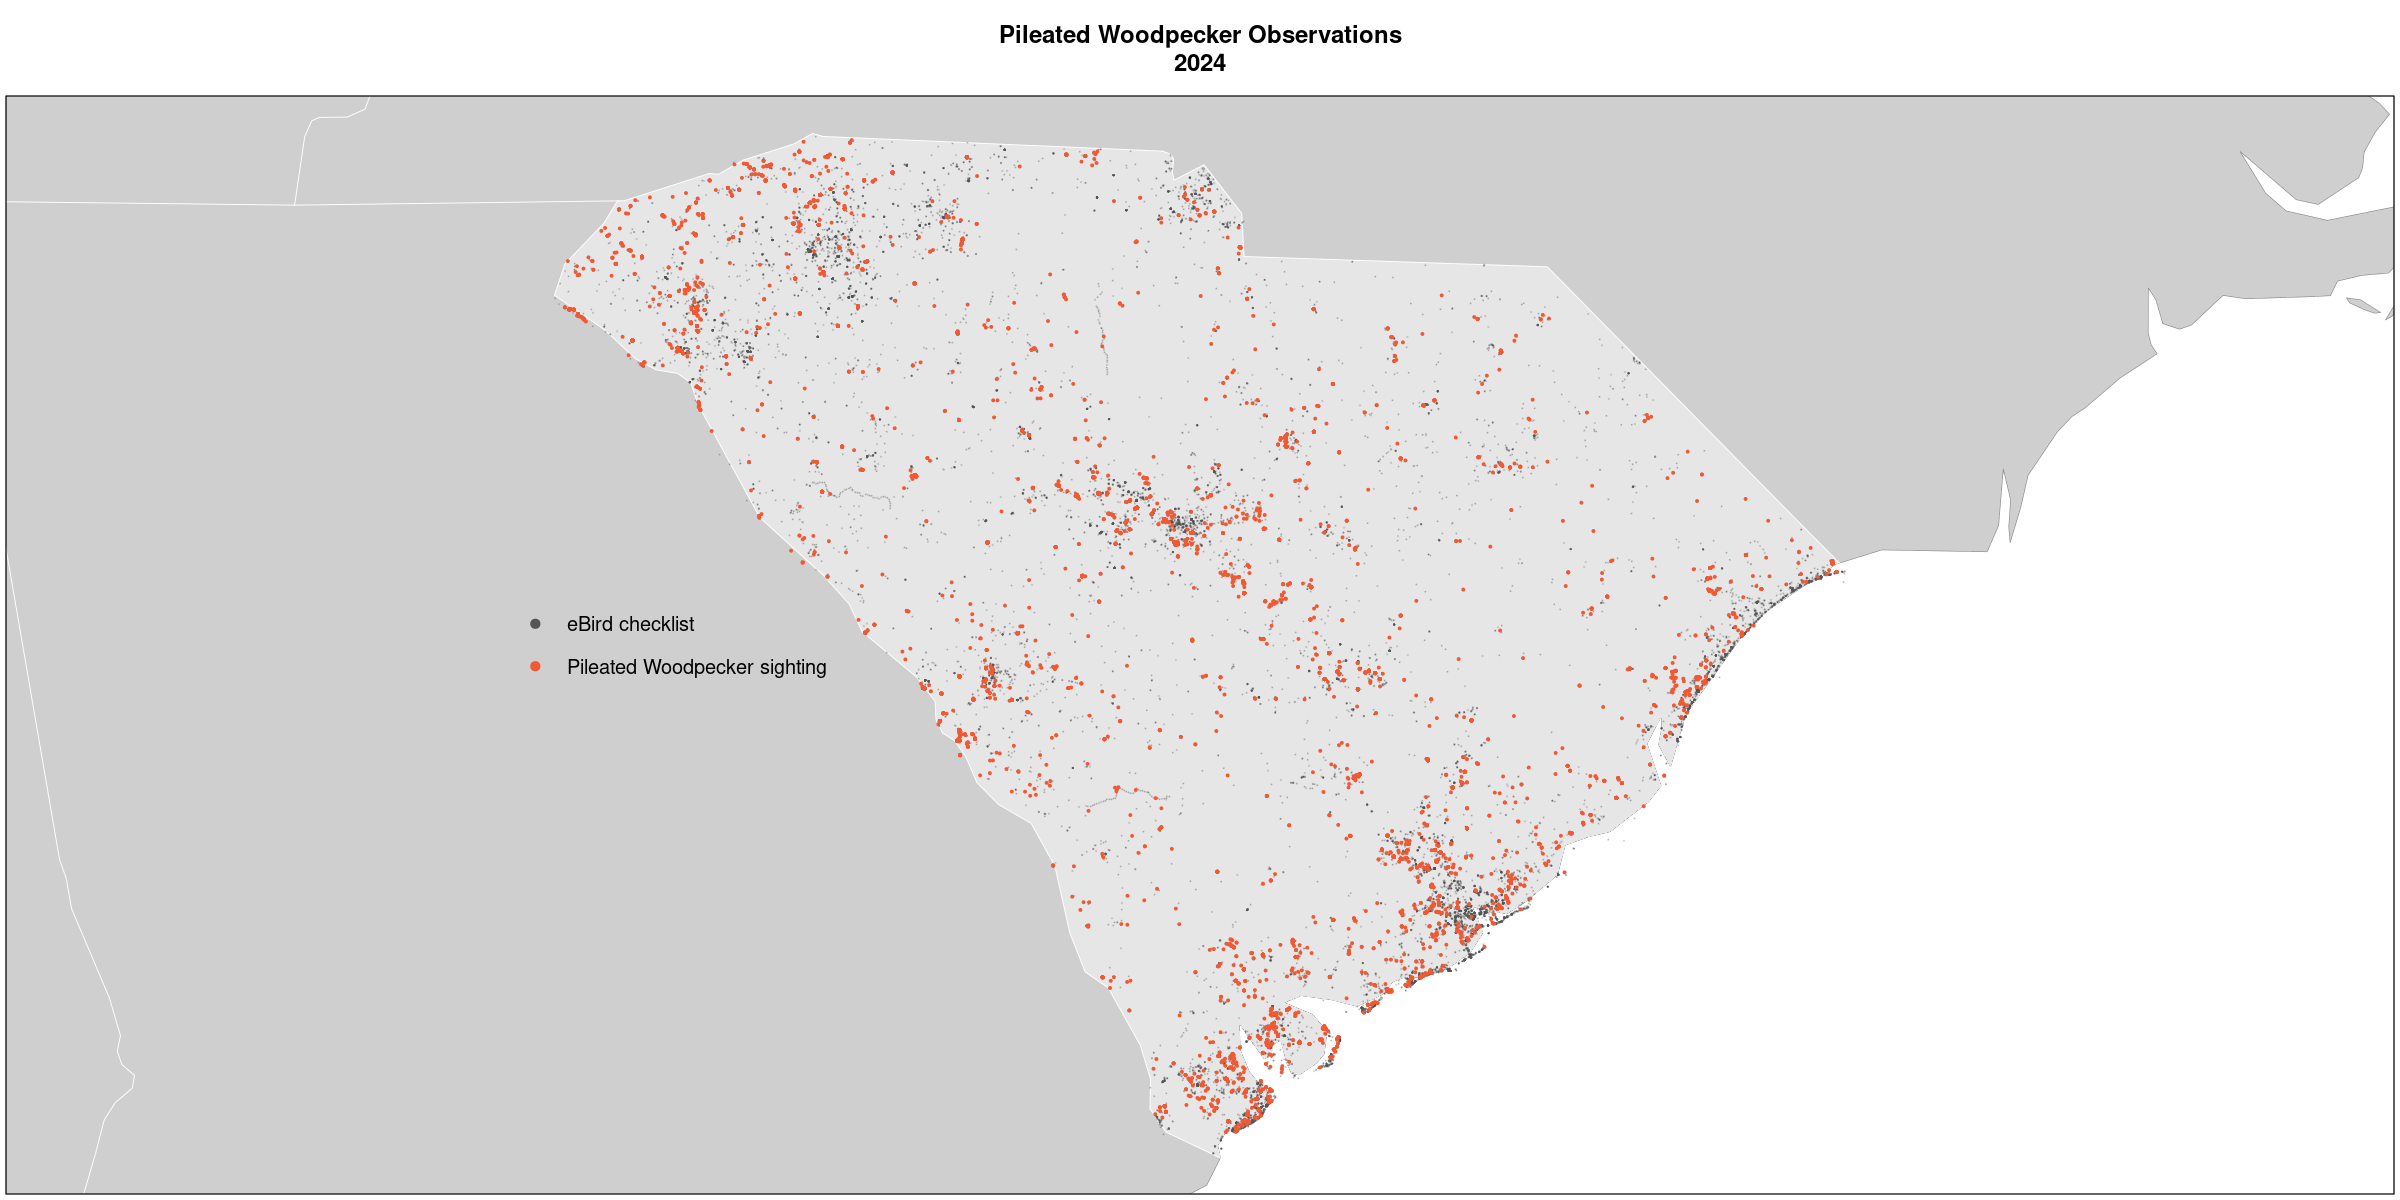

In [ ]:
# load gis data
ne_land <- read_sf(file.path(workshop_data_path, "gis-data.gpkg"), "ne_land") |> 
  st_geometry()
ne_country_lines <- read_sf(file.path(workshop_data_path, "gis-data.gpkg"), "ne_country_lines") |> 
  st_geometry()
ne_state_lines <- read_sf(file.path(workshop_data_path, "gis-data.gpkg"), "ne_state_lines") |> 
  st_geometry()
study_region <- read_sf(file.path(workshop_data_path, "gis-data.gpkg"), "ne_states") |> 
  filter(state_code == "US-SC") |> 
  st_geometry()

# prepare ebird data for mapping
checklists_sf <- checklists |> 
  # convert to spatial points
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326) |> 
  select(species_observed)

# map
par(mar = c(0.25, 0.25, 4, 0.25))
# set up plot area
plot(st_geometry(checklists_sf), 
     main = "Pileated Woodpecker Observations\n2024",
     col = NA, border = NA)
# contextual gis data
plot(ne_land, col = "#cfcfcf", border = "#888888", lwd = 0.5, add = TRUE)
plot(study_region, col = "#e6e6e6", border = NA, add = TRUE)
plot(ne_state_lines, col = "#ffffff", lwd = 0.75, add = TRUE)
plot(ne_country_lines, col = "#ffffff", lwd = 1.5, add = TRUE)
# ebird observations
# not observed
plot(filter(checklists_sf, !species_observed),
     pch = 19, cex = 0.1, col = alpha("#555555", 0.25),
     add = TRUE)
# observed
plot(filter(checklists_sf, species_observed),
     pch = 19, cex = 0.3, col = alpha("#f05933ff", 1),
     add = TRUE)
# legend
legend("left", bty = "n",
       col = c("#555555", "#f05933ff"),
       legend = c("eBird checklist", "Pileated Woodpecker sighting"),
       pch = 19)
box()
# https://ebird.github.io/ebird-best-practices/ebird.html#sec-ebird-explore

#### other way that's not working well
---
https://strimas.com/ebp-workshop/applications.html

In [ ]:
par(mar = c(0.25, 0.25, 1.25, 0.25))
# set up plot area
plot(study_region, 
     main = "Wood Thrush Range (June 2023)",
     col = NA, border = NA)
plot(ne_land, col = "#cfcfcf", border = "#888888", lwd = 0.5, add = TRUE)

# convert binary prediction to categorical
r_range <- as.factor(r_pred[["in_range"]])
plot(r_range, col = c("#e6e6e6", "forestgreen"),
     maxpixels = ncell(r_range),
     legend = FALSE, axes = FALSE, bty = "n",
     add = TRUE)

# borders
plot(ne_state_lines, col = "#ffffff", lwd = 0.75, add = TRUE)
plot(ne_country_lines, col = "#ffffff", lwd = 1.5, add = TRUE)
plot(study_region, border = "#000000", col = NA, lwd = 1, add = TRUE)
box()

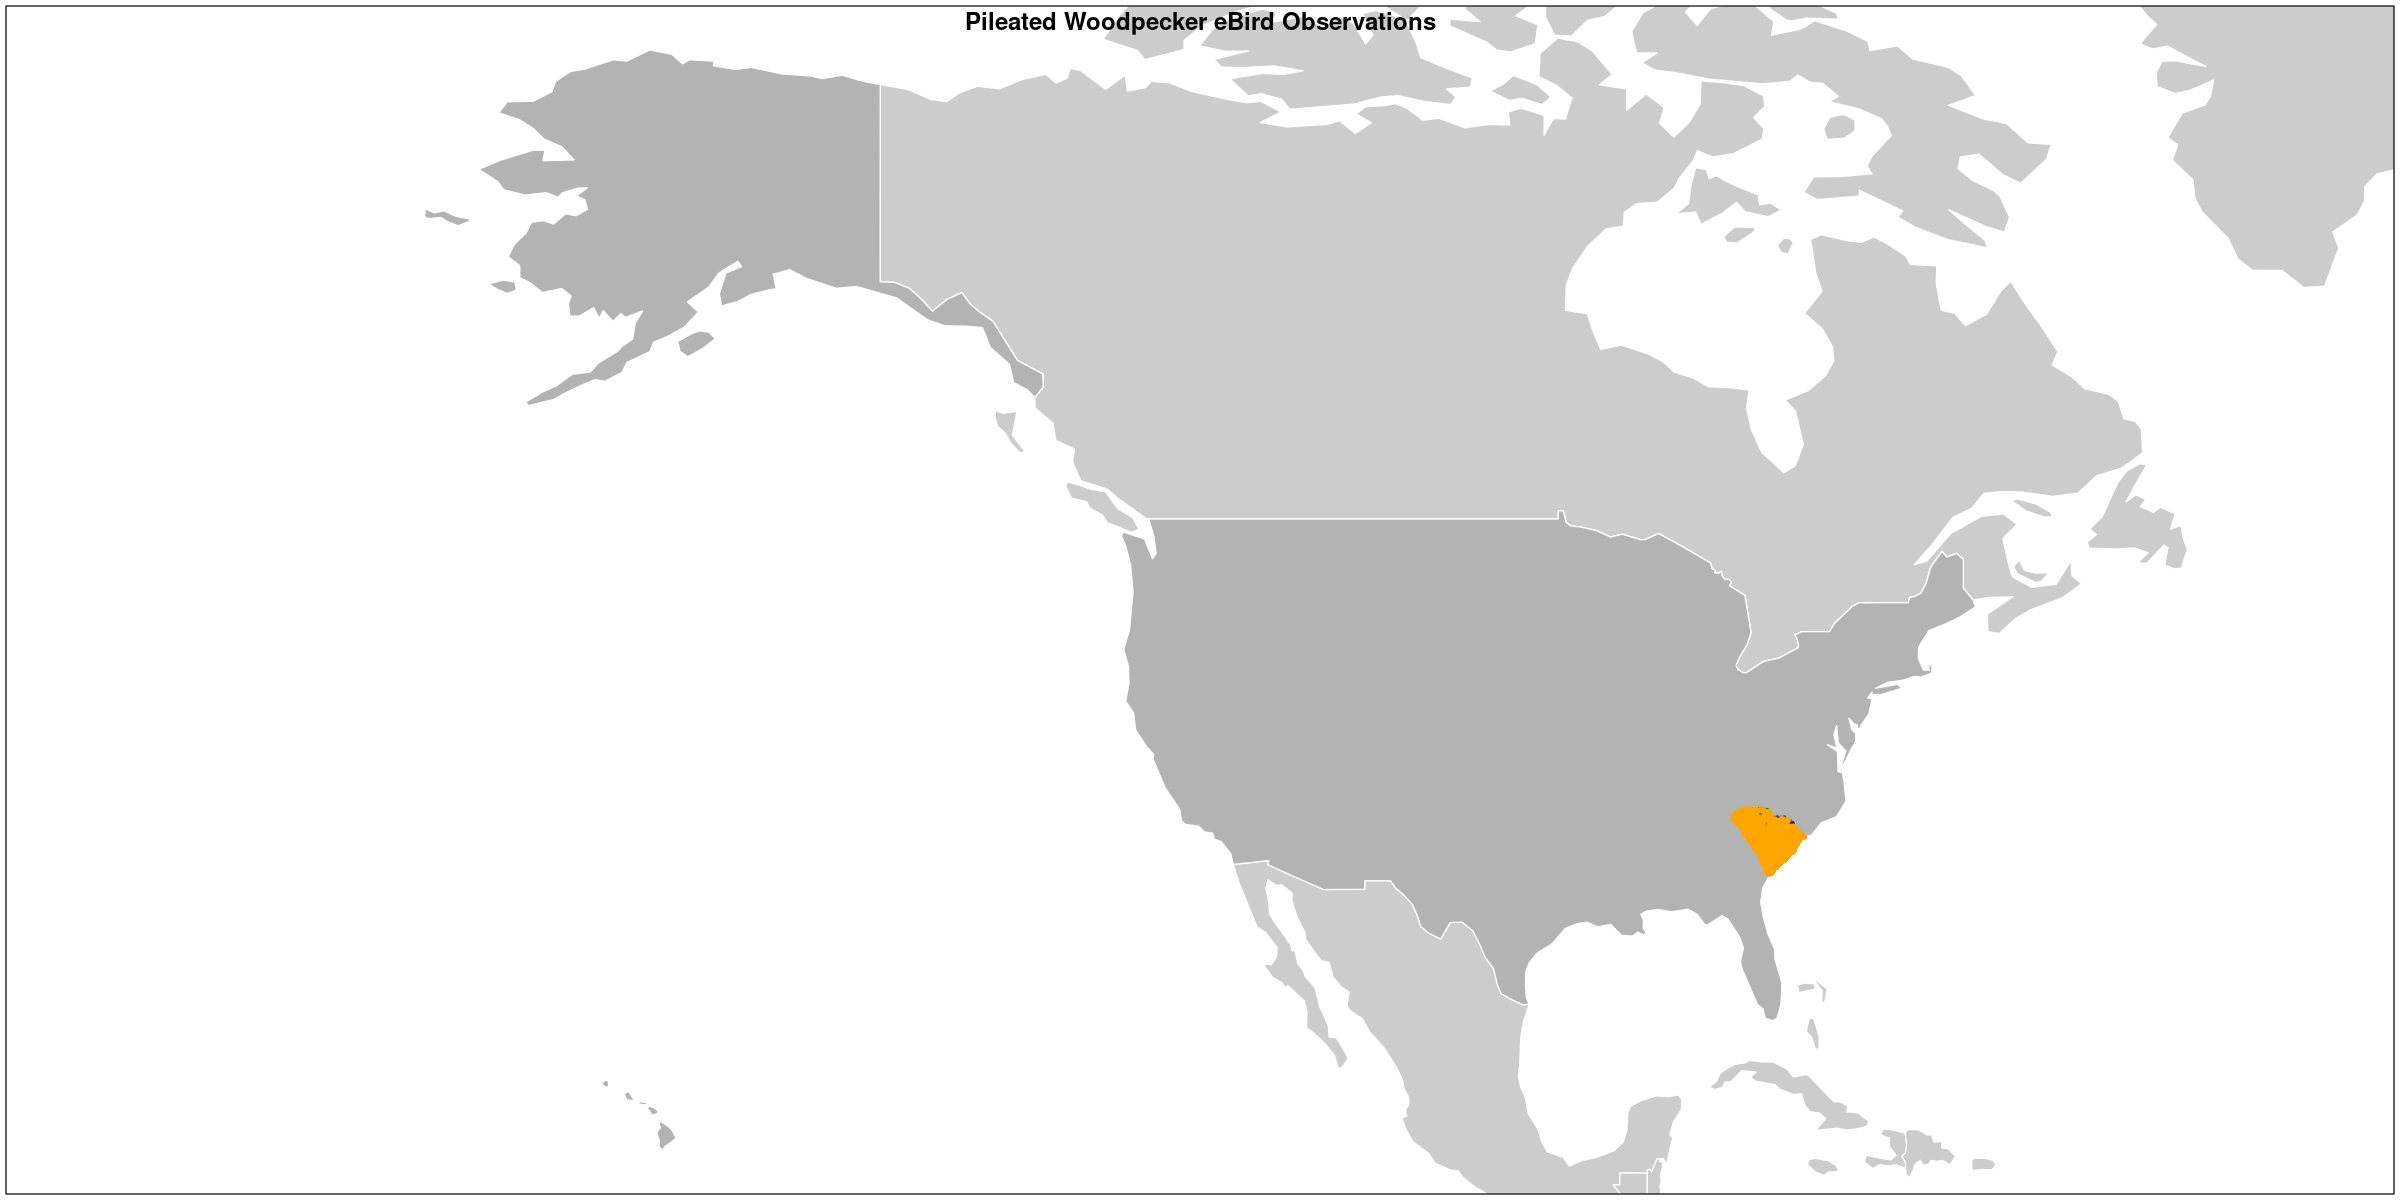

In [ ]:
par(mar = c(0.25, 0.25, 0.25, 0.25))
# start by defining the bounds of the map with an empty plot
plot(ne_gt, col = NA, border = NA)
# borders
plot(ne_country, col = "grey80", border = "white", add = TRUE)
plot(ne_gt, col = "grey70", border = "white", add = TRUE)
# not observed
ebird_spatial_abs <- filter(ebird_spatial, !species_observed) %>% 
  st_geometry()
plot(ebird_spatial_abs, col = alpha("grey20", 0.3), pch = 19, cex = 0.25, add = TRUE)
# present
ebird_pres <- filter(ebird_spatial, species_observed) %>% 
  st_geometry()
plot(ebird_pres, col = alpha("orange", 1), pch = 19, cex = 0.5, add = TRUE)
title("Pileated Woodpecker eBird Observations", line = -1)
legend("bottomright", 
       col = c("grey20", "orange"),
       legend = c("Not reported", "Present"),
       pch = 19)
box()

### add dist to coast and elevation

In [190]:
str(ebird_filtered_agg)

tibble [728 × 11] (S3: tbl_df/tbl/data.frame)
 $ cell              : num [1:728] 493475 493476 493477 493478 493479 ...
 $ n_checklists      : int [1:728] 1 11 164 20 10 2 35 5 15 86 ...
 $ n_detected        : int [1:728] 0 8 77 4 5 0 10 2 5 20 ...
 $ det_freq          : num [1:728] 0 0.727 0.47 0.2 0.5 ...
 $ mean_num_observers: num [1:728] 2 1.55 1.12 1.2 2 ...
 $ mean_start_time_hr: num [1:728] 12.78 10.12 10.93 9.82 11.25 ...
 $ med_duration      : num [1:728] 0.417 2.35 0.592 0.333 1.083 ...
 $ mean_dist_km      : num [1:728] 1.043 2.238 0.427 0.408 2.41 ...
 $ cell_ctr_lat      : num [1:728] 35.1 35.1 35.2 35.2 35.2 ...
 $ cell_ctr_lon      : num [1:728] -82.8 -82.7 -82.5 -82.4 -82.3 ...
 $ type              : chr [1:728] "test" "train" "test" "train" ...


In [26]:
ebird_filtered_agg = add_dist_to_coast(dist_to_coast_df, ebird_filtered_agg)

In [194]:
ebird_filtered_agg = add_elev_data(ebird_filtered_agg)
str(ebird_filtered_agg)

tibble [728 × 12] (S3: tbl_df/tbl/data.frame)
 $ cell              : num [1:728] 493475 493476 493477 493478 493479 ...
 $ n_checklists      : int [1:728] 1 11 164 20 10 2 35 5 15 86 ...
 $ n_detected        : int [1:728] 0 8 77 4 5 0 10 2 5 20 ...
 $ det_freq          : num [1:728] 0 0.727 0.47 0.2 0.5 ...
 $ mean_num_observers: num [1:728] 2 1.55 1.12 1.2 2 ...
 $ mean_start_time_hr: num [1:728] 12.78 10.12 10.93 9.82 11.25 ...
 $ med_duration      : num [1:728] 0.417 2.35 0.592 0.333 1.083 ...
 $ mean_dist_km      : num [1:728] 1.043 2.238 0.427 0.408 2.41 ...
 $ cell_ctr_lat      : num [1:728] 35.1 35.1 35.2 35.2 35.2 ...
 $ cell_ctr_lon      : num [1:728] -82.8 -82.7 -82.5 -82.4 -82.3 ...
 $ type              : chr [1:728] "test" "train" "test" "train" ...
 $ elevation         : num [1:728] 2690 3010 2850 2277 2385 ...


In [179]:
write_elev_local_file(ebird_filtered_agg)